<a href="https://colab.research.google.com/github/Rehanabbaxi/Machine_Learning_Practice/blob/main/Chapetr_03_Classification_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml

mnist =  fetch_openml("mnist_784" , as_frame=False)


In [2]:
X , y = mnist.data , mnist.target
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_digit(data):
    image = data.reshape(28,28)
    plt.imshow(image , cmap="binary")
    plt.axis("off")
    plt.show()

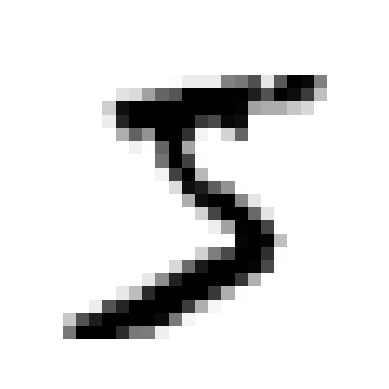

In [4]:
sample_digit = X[0]
plot_digit(sample_digit)
plt.show()

In [5]:
X_train , y_train , X_test , y_test =  X[:60000] , y[:60000] , X[6000:] , y[6000:]

In [6]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 784)
(60000,)
(64000, 784)
(64000,)


In [7]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [8]:
from sklearn.linear_model import SGDClassifier

sdg_clf = SGDClassifier(random_state=42)
sdg_clf.fit(X_train , y_train_5)

SGDClassifier(random_state=42)

In [9]:
predictio = sdg_clf.predict([sample_digit])
print(predictio)

[ True]


In [10]:
from sklearn.model_selection import cross_val_score
cross_val_score(sdg_clf , X_train , y_train_5 , cv=3 , scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [11]:
from sklearn.dummy import DummyClassifier

dumyy_cl  =  DummyClassifier()
dumyy_cl.fit(X_train , y_train_5)
cross_val_score(dumyy_cl , X_train , y_train_5 , cv=3 , scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

Confusion Matrix

In [12]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sdg_clf , X_train , y_train_5 , cv=3)

In [18]:
print(len(y_train_pred))

60000


In [19]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5 , y_train_pred)
print(cm)

[[53892   687]
 [ 1891  3530]]


In [21]:
from sklearn.metrics import precision_score , recall_score
precision_score(y_train_5 , y_train_pred)

0.8370879772350012

In [22]:
recall_score(y_train_5 , y_train_pred)

0.6511713705958311

In [23]:
from sklearn.metrics import f1_score
f1_score(y_train_5 , y_train_pred)

0.7325171197343847

In [25]:
y_score = sdg_clf.decision_function([sample_digit])
y_score

array([2164.22030239])

In [26]:
threshold = 0
y_some_digit_pred = (y_score > threshold)
y_some_digit_pred

array([ True])

In [28]:
threshold = 3000
y_some_digit_pred = (y_score > threshold)
y_some_digit_pred

array([False])

In [29]:
y_score = cross_val_predict(sdg_clf , X_train , y_train_5 , cv=3 , method="decision_function")

In [31]:
from sklearn.metrics import precision_recall_curve

precisions , recalls ,  thresholds = precision_recall_curve(y_train_5 , y_score)

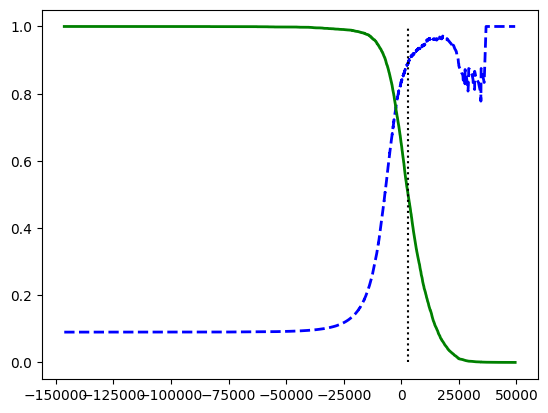

In [32]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")